# Exploratory Data Analysis (EDA) & Discovery

## Data Acquisition

### Preparation

#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine, text

from wgnd.core.theme import setup
from wgnd.inspect import (
    inspect,
    inspect_missing,
    inspect_outliers,
    inspect_outlier_detail,
    inspect_correlations,
)

setup()

✓  wgnd theme activated (matplotlib · seaborn)

#### Settings

In [2]:
%load_ext autoreload
%autoreload 2

#### Constants

In [3]:
DATA_RAW = Path('../data/raw')
DB_PATH = DATA_RAW / 'telco_churn.db'

### Data Gathering

In [4]:
# City names are loaded via JOIN directly (saves a second DB call + merge)
engine = create_engine(f"sqlite:///{DB_PATH}")

query = """
    SELECT
        ch.account_length,
        ch.international_plan,
        ch.voice_mail_plan,
        ch.number_vmail_messages,
        ch.total_day_minutes,
        ch.total_day_calls,
        ch.total_day_charge,
        ch.total_eve_minutes,
        ch.total_eve_calls,
        ch.total_eve_charge,
        ch.total_night_minutes,
        ch.total_night_calls,
        ch.total_night_charge,
        ch.customer_service_calls,
        ch.churn,
        ch.phone_num,
        ci.city,
        ci.area_code
    FROM churn_data AS ch
    LEFT JOIN cities AS ci
    ON ch.local_area_code = ci.area_code
"""

with engine.connect() as conn:
    df_raw = pd.read_sql(text(query), conn)

df_raw.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,customer_service_calls,churn,phone_num,city,area_code
0,131.0,no,no,0.0,187.9,110.0,31.94,200.5,101.0,17.04,202.6,125.0,9.12,2.0,0.0,1473.0,Tallahassee,850.0
1,63.0,yes,yes,21.0,151.5,99.0,25.76,147.8,89.0,12.56,210.4,114.0,9.47,1.0,0.0,8029.0,Miami2,786.0
2,13.0,no,no,0.0,303.2,133.0,51.54,170.5,86.0,14.49,227.6,80.0,10.24,0.0,1.0,7468.0,Jacksonville,904.0
3,129.0,no,no,0.0,159.1,100.0,27.05,202.5,90.0,17.21,233.1,96.0,10.49,2.0,0.0,4979.0,Miami1,305.0
4,120.0,no,yes,28.0,215.8,123.0,36.69,285.2,76.0,24.24,192.1,78.0,8.64,1.0,0.0,9620.0,Cape Coral,239.0


## Analysis

### Basic Statistical Analysis

> _Vollständige EDA-Übersicht mit wgnd.inspect._


───  DIMENSIONS  ─────────────────────────────────────────────


,metric,count,pct
0,rows,3349,
1,columns,18,
2,duplicates,15,0.45%
3,empty rows (all NaN),16,0.48%
4,empty cols (all NaN),0,0.0%



───  MEMORY  ─────────────────────────────────────────────────


,column,dtype,memory_kb,memory_pct
0,city,object,216.27,21.74%
1,voice_mail_plan,object,193.31,19.43%
2,international_plan,object,192.73,19.37%
3,account_length,float64,26.16,2.63%
4,total_day_minutes,float64,26.16,2.63%
5,number_vmail_messages,float64,26.16,2.63%
6,total_day_charge,float64,26.16,2.63%
7,total_eve_minutes,float64,26.16,2.63%
8,total_eve_calls,float64,26.16,2.63%
9,total_day_calls,float64,26.16,2.63%


Total: 994.9 KB  (0.97 MB)

───  DTYPES  ─────────────────────────────────────────────────


,column,dtype,missing_cnt,missing_pct,unique,unique_pct
0,account_length,float64,16,0.48%,212,6.33%
1,international_plan,object,16,0.48%,2,0.06%
2,voice_mail_plan,object,16,0.48%,2,0.06%
3,number_vmail_messages,float64,38,1.13%,46,1.37%
4,total_day_minutes,float64,16,0.48%,1667,49.78%
5,total_day_calls,float64,27,0.81%,119,3.55%
6,total_day_charge,float64,16,0.48%,1667,49.78%
7,total_eve_minutes,float64,16,0.48%,1611,48.10%
8,total_eve_calls,float64,24,0.72%,123,3.67%
9,total_eve_charge,float64,16,0.48%,1440,43.00%



───  COLUMN NAMES  ───────────────────────────────────────────
✓  All column names are Python-compatible.
All 18: account_length, international_plan, voice_mail_plan, number_vmail_messages, total_day_minutes, total_day_calls, total_day_charge, total_eve_minutes, total_eve_calls, total_eve_charge, total_night_minutes, total_night_calls, total_night_charge, customer_service_calls, churn, phone_num, city, area_code

───  MISSING VALUES  ─────────────────────────────────────────


,column,missing_cnt,missing_pct
0,number_vmail_messages,38,1.13%
1,total_day_calls,27,0.81%
2,total_eve_calls,24,0.72%
3,total_night_calls,21,0.63%
4,international_plan,16,0.48%
5,account_length,16,0.48%
6,total_day_minutes,16,0.48%
7,total_day_charge,16,0.48%
8,total_eve_minutes,16,0.48%
9,voice_mail_plan,16,0.48%


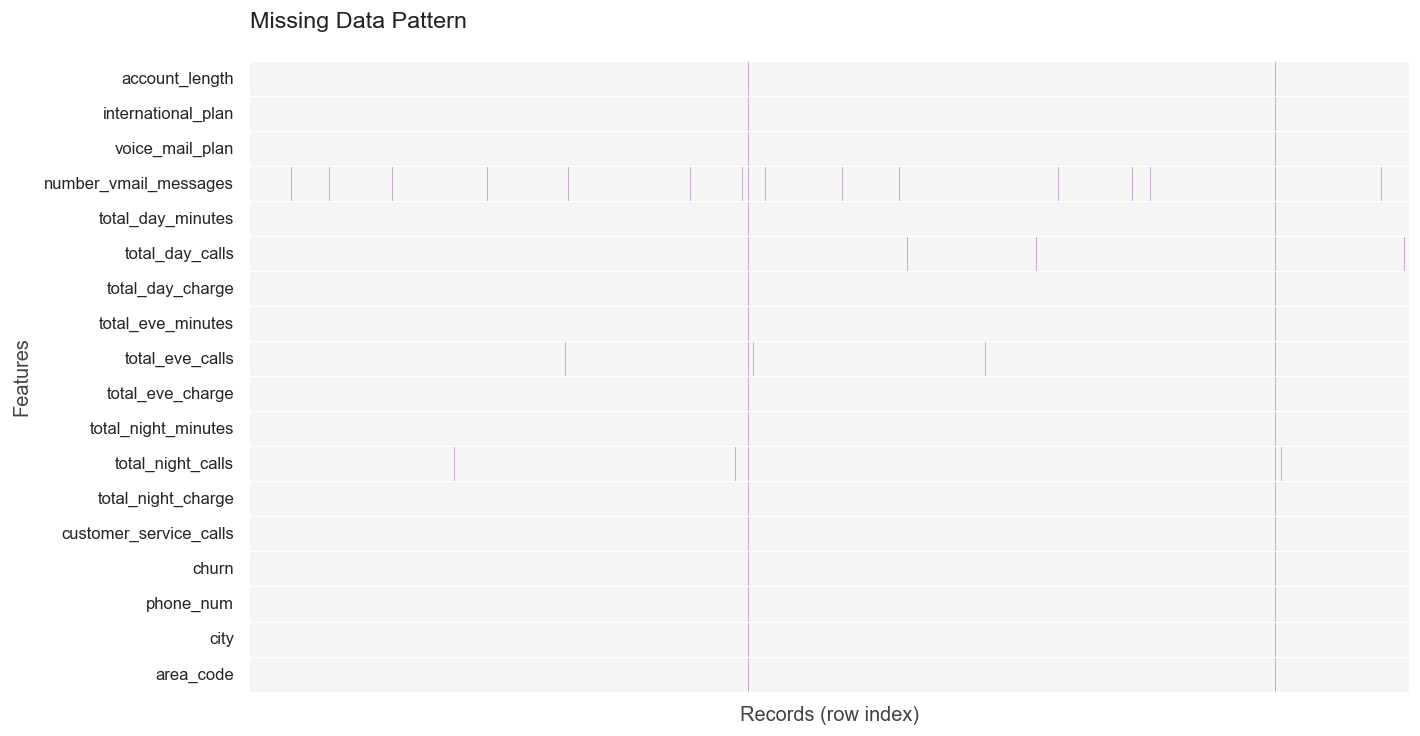


───  DUPLICATES  ─────────────────────────────────────────────


,metric,count,pct
0,total rows,3349,
1,duplicates,15,0.45%
2,unique rows,3334,99.55%


Duplicate rows returned — use result.head(10) to inspect.

───  NUMERIC STATS  ──────────────────────────────────────────


,column,missing_pct,count,mean,median,std,min,25%,75%,max,mean_median_diff,skewness
0,account_length,0.48%,3333.00,101.06,101.00,39.82,1.00,74.00,127.00,243.00,0.06,0.10
1,number_vmail_messages,1.13%,3311.00,8.15,0.00,13.72,0.00,0.00,20.00,51.00,8.15,1.25
2,total_day_minutes,0.48%,3333.00,179.88,179.40,54.86,0.00,143.70,216.40,448.60,0.48,0.05
3,total_day_calls,0.81%,3322.00,100.41,101.00,20.05,0.00,87.00,114.00,165.00,-0.59,-0.11
4,total_day_charge,0.48%,3333.00,30.56,30.50,9.26,0.00,24.43,36.79,59.64,0.06,-0.03
5,total_eve_minutes,0.48%,3333.00,200.98,201.40,50.71,0.00,166.60,235.30,363.70,-0.42,-0.02
6,total_eve_calls,0.72%,3325.00,100.11,100.00,19.90,0.00,87.00,114.00,170.00,0.11,-0.06
7,total_eve_charge,0.48%,3333.00,17.08,17.12,4.31,0.00,14.16,20.00,30.91,-0.04,-0.02
8,total_night_minutes,0.48%,3333.00,200.87,201.20,50.57,23.20,167.00,235.30,395.00,-0.33,0.01
9,total_night_calls,0.63%,3328.00,100.12,100.00,19.55,33.00,87.00,113.00,175.00,0.12,0.03



───  CATEGORICAL STATS  ──────────────────────────────────────


,column,missing_pct,missing_cnt,uniques,top_value,top_value_cnt,top_value_freq_pct
0,international_plan,0.48%,16,2,no,3010,89.88%
1,voice_mail_plan,0.48%,16,2,no,2411,71.99%
2,city,0.48%,16,12,Jacksonville,332,9.91%



───  CORRELATIONS  ───────────────────────────────────────────


,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,customer_service_calls,churn,phone_num,area_code
account_length,1.00,-0.00,0.01,0.04,0.01,-0.01,0.02,-0.01,-0.01,-0.01,-0.01,-0.01,0.02,-0.02,0.03
number_vmail_messages,-0.00,1.00,-0.00,-0.01,0.00,0.02,-0.00,0.02,0.01,0.01,0.01,-0.02,-0.09,0.03,0.01
total_day_minutes,0.01,-0.00,1.00,0.00,1.00,0.01,0.02,0.01,0.00,0.02,0.00,-0.01,0.21,0.02,-0.01
total_day_calls,0.04,-0.01,0.00,1.00,0.01,-0.02,0.01,-0.02,0.02,-0.02,0.02,-0.01,0.02,-0.01,0.00
total_day_charge,0.01,0.00,1.00,0.01,1.00,0.01,0.02,0.01,0.00,0.02,0.00,-0.01,0.21,0.01,-0.01
total_eve_minutes,-0.01,0.02,0.01,-0.02,0.01,1.00,-0.01,1.00,-0.01,0.01,-0.01,-0.02,0.09,-0.00,-0.03
total_eve_calls,0.02,-0.00,0.02,0.01,0.02,-0.01,1.00,-0.01,-0.00,0.01,-0.00,0.01,0.01,0.02,-0.03
total_eve_charge,-0.01,0.02,0.01,-0.02,0.01,1.00,-0.01,1.00,-0.01,0.01,-0.01,-0.02,0.09,-0.00,-0.03
total_night_minutes,-0.01,0.01,0.00,0.02,0.00,-0.01,-0.00,-0.01,1.00,0.01,1.00,-0.01,0.04,-0.01,0.01
total_night_calls,-0.01,0.01,0.02,-0.02,0.02,0.01,0.01,0.01,0.01,1.00,0.01,-0.02,0.01,0.01,-0.01


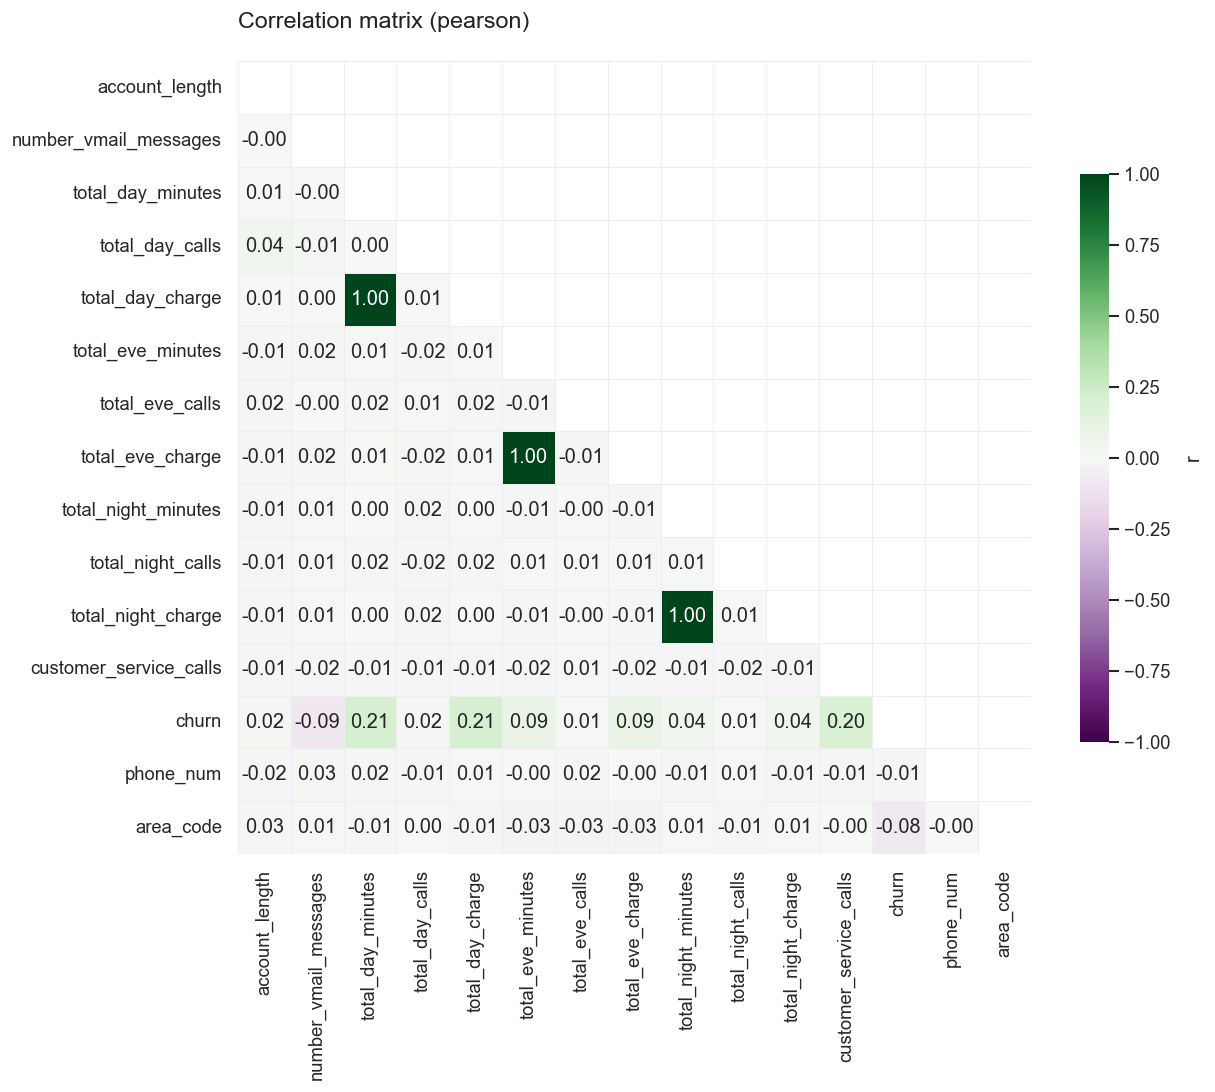

3 highly correlated pair(s) (|r| ≥ 0.8): total_day_minutes↔total_day_charge, total_night_minutes↔total_night_charge, total_eve_minutes↔total_eve_charge


⚠  3 highly correlated pair(s) (|r| ≥ 0.8): total_day_minutes↔total_day_charge, total_night_minutes↔total_night_charge, total_eve_minutes↔total_eve_charge

───  OUTLIERS  ───────────────────────────────────────────────


,column,mean,median,mean_med_diff,lower_1.5x,upper_1.5x,outliers_1.5x,outliers_1.5x_%,lower_3x,upper_3x,outliers_3x,outliers_3x_%
0,churn,0.14,0.00,0.14,0.00,0.00,483,14.49%,0.00,0.00,483,14.49%
1,customer_service_calls,1.53,1.00,0.53,-0.50,3.50,304,9.12%,-2.00,5.00,35,1.05%
2,total_night_minutes,200.87,201.20,-0.33,64.55,337.75,30,0.90%,-37.90,440.20,0,0.00%
3,total_night_charge,9.04,9.05,-0.01,2.91,15.20,30,0.90%,-1.69,19.80,0,0.00%
4,total_day_minutes,179.88,179.40,0.48,34.65,325.45,27,0.81%,-74.40,434.50,2,0.06%
5,total_day_charge,30.56,30.50,0.06,5.89,55.33,25,0.75%,-12.65,73.87,0,0.00%
6,total_eve_minutes,200.98,201.40,-0.42,63.55,338.35,24,0.72%,-39.50,441.40,0,0.00%
7,total_eve_charge,17.08,17.12,-0.04,5.40,28.76,24,0.72%,-3.36,37.52,0,0.00%
8,total_day_calls,100.41,101.00,-0.59,46.50,154.50,23,0.69%,6.00,195.00,2,0.06%
9,total_night_calls,100.12,100.00,0.12,48.00,152.00,22,0.66%,9.00,191.00,0,0.00%


→ inspect_outlier_detail(df, col) for boxplot+histogram per feature.


In [5]:
df_eda = df_raw.copy()
inspect(df_eda)   # alle Sektionen auf einmal

# Einzelne Sektionen:
# inspect(df_eda, sections=['dimensions', 'dtypes', 'missing'])

### Data Completeness

* Quality Check
* Duplicates
* Missing Values


───  MISSING VALUES  ─────────────────────────────────────────


,column,missing_cnt,missing_pct
0,number_vmail_messages,38,1.13%
1,total_day_calls,27,0.81%
2,total_eve_calls,24,0.72%
3,total_night_calls,21,0.63%
4,international_plan,16,0.48%
5,account_length,16,0.48%
6,total_day_minutes,16,0.48%
7,total_day_charge,16,0.48%
8,total_eve_minutes,16,0.48%
9,voice_mail_plan,16,0.48%


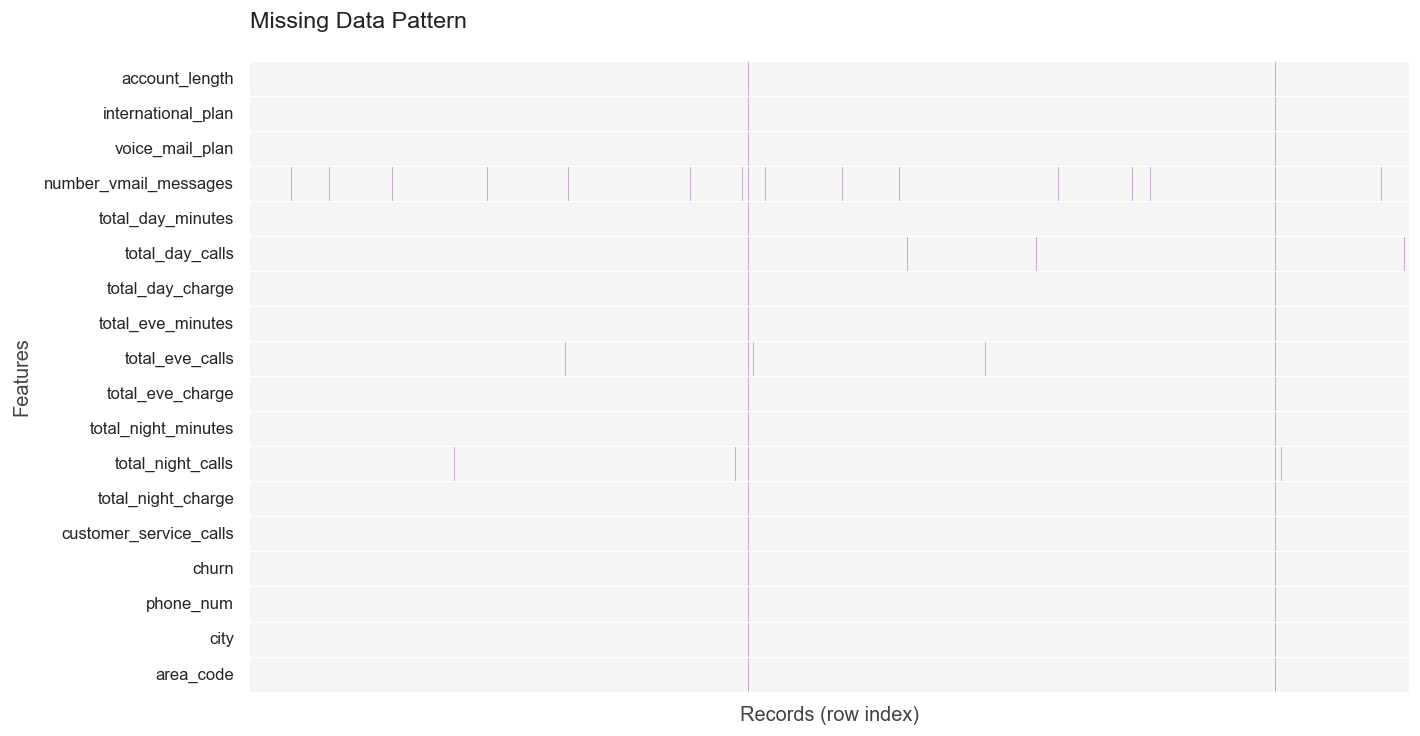

,column,missing_cnt,missing_pct
0,number_vmail_messages,38,1.13
1,total_day_calls,27,0.81
2,total_eve_calls,24,0.72
3,total_night_calls,21,0.63
4,international_plan,16,0.48
5,account_length,16,0.48
6,total_day_minutes,16,0.48
7,total_day_charge,16,0.48
8,total_eve_minutes,16,0.48
9,voice_mail_plan,16,0.48


In [6]:
inspect_missing(df_eda)

### Data Integrity

* Invalid Data Detection
* Plausibility Check

In [7]:
# Plausibility check: expected value ranges of the categorical columns
print("international_plan:", df_eda['international_plan'].dropna().unique())
print("voice_mail_plan:", df_eda['voice_mail_plan'].dropna().unique())
print("churn:", df_eda['churn'].dropna().unique())
print("Number of cities:", df_eda['city'].nunique())
print()

# Plausibility check: negative values in count columns are impossible
count_cols = ['account_length', 'number_vmail_messages', 'total_day_calls',
              'total_eve_calls', 'total_night_calls', 'customer_service_calls']
for col in count_cols:
    neg = (df_eda[col] < 0).sum()
    if neg:
        print(f"⚠ {col}: {neg} rows with negative value (min={df_eda[col].min()}) "
              f"-- not plausible, will be fixed in 02_preparation")

international_plan: ['no' 'yes']
voice_mail_plan: ['no' 'yes']
churn: [0. 1.]
Number of cities: 12

⚠ customer_service_calls: 37 rows with negative value (min=-2.0) -- not plausible, will be fixed in 02_preparation


### Data Distribution

* Numerical Features
* Categorical Features
* Bivariate Analysis

international_plan
no     0.90309
yes    0.09691
Name: proportion, dtype: float64

voice_mail_plan
no     0.723372
yes    0.276628
Name: proportion, dtype: float64

Churn rate (overall): 14.49 %


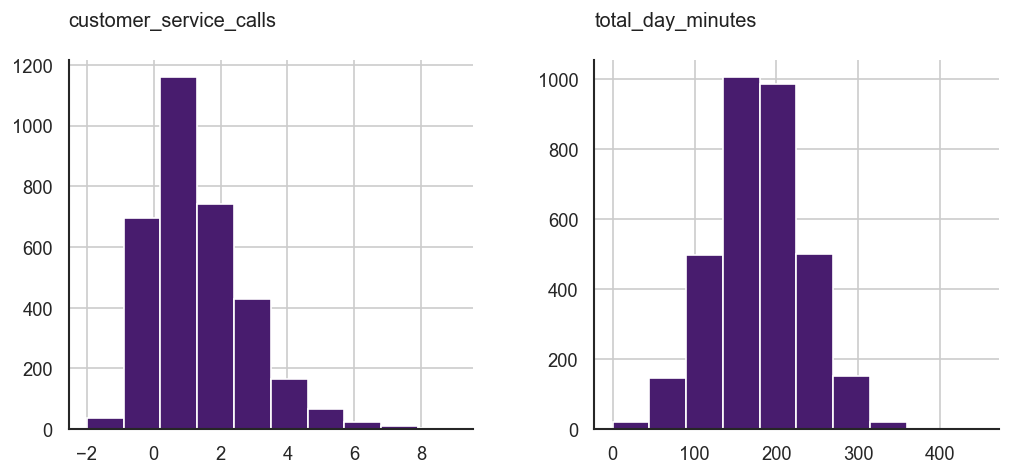

In [8]:
# Categorical distribution
for col in ['international_plan', 'voice_mail_plan']:
    print(df_eda[col].value_counts(normalize=True))
    print()

# Baseline churn rate
print("Churn rate (overall):", round(df_eda['churn'].mean() * 100, 2), "%")

# Numeric distribution (example: columns relevant later)
df_eda[['customer_service_calls', 'total_day_minutes']].hist(figsize=(10, 4))
plt.show()

### Data Relationships

* Correlations


───  CORRELATIONS  ───────────────────────────────────────────


,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,customer_service_calls,churn,phone_num,area_code
account_length,1.00,-0.00,0.01,0.04,0.01,-0.01,0.02,-0.01,-0.01,-0.01,-0.01,-0.01,0.02,-0.02,0.03
number_vmail_messages,-0.00,1.00,-0.00,-0.01,0.00,0.02,-0.00,0.02,0.01,0.01,0.01,-0.02,-0.09,0.03,0.01
total_day_minutes,0.01,-0.00,1.00,0.00,1.00,0.01,0.02,0.01,0.00,0.02,0.00,-0.01,0.21,0.02,-0.01
total_day_calls,0.04,-0.01,0.00,1.00,0.01,-0.02,0.01,-0.02,0.02,-0.02,0.02,-0.01,0.02,-0.01,0.00
total_day_charge,0.01,0.00,1.00,0.01,1.00,0.01,0.02,0.01,0.00,0.02,0.00,-0.01,0.21,0.01,-0.01
total_eve_minutes,-0.01,0.02,0.01,-0.02,0.01,1.00,-0.01,1.00,-0.01,0.01,-0.01,-0.02,0.09,-0.00,-0.03
total_eve_calls,0.02,-0.00,0.02,0.01,0.02,-0.01,1.00,-0.01,-0.00,0.01,-0.00,0.01,0.01,0.02,-0.03
total_eve_charge,-0.01,0.02,0.01,-0.02,0.01,1.00,-0.01,1.00,-0.01,0.01,-0.01,-0.02,0.09,-0.00,-0.03
total_night_minutes,-0.01,0.01,0.00,0.02,0.00,-0.01,-0.00,-0.01,1.00,0.01,1.00,-0.01,0.04,-0.01,0.01
total_night_calls,-0.01,0.01,0.02,-0.02,0.02,0.01,0.01,0.01,0.01,1.00,0.01,-0.02,0.01,0.01,-0.01


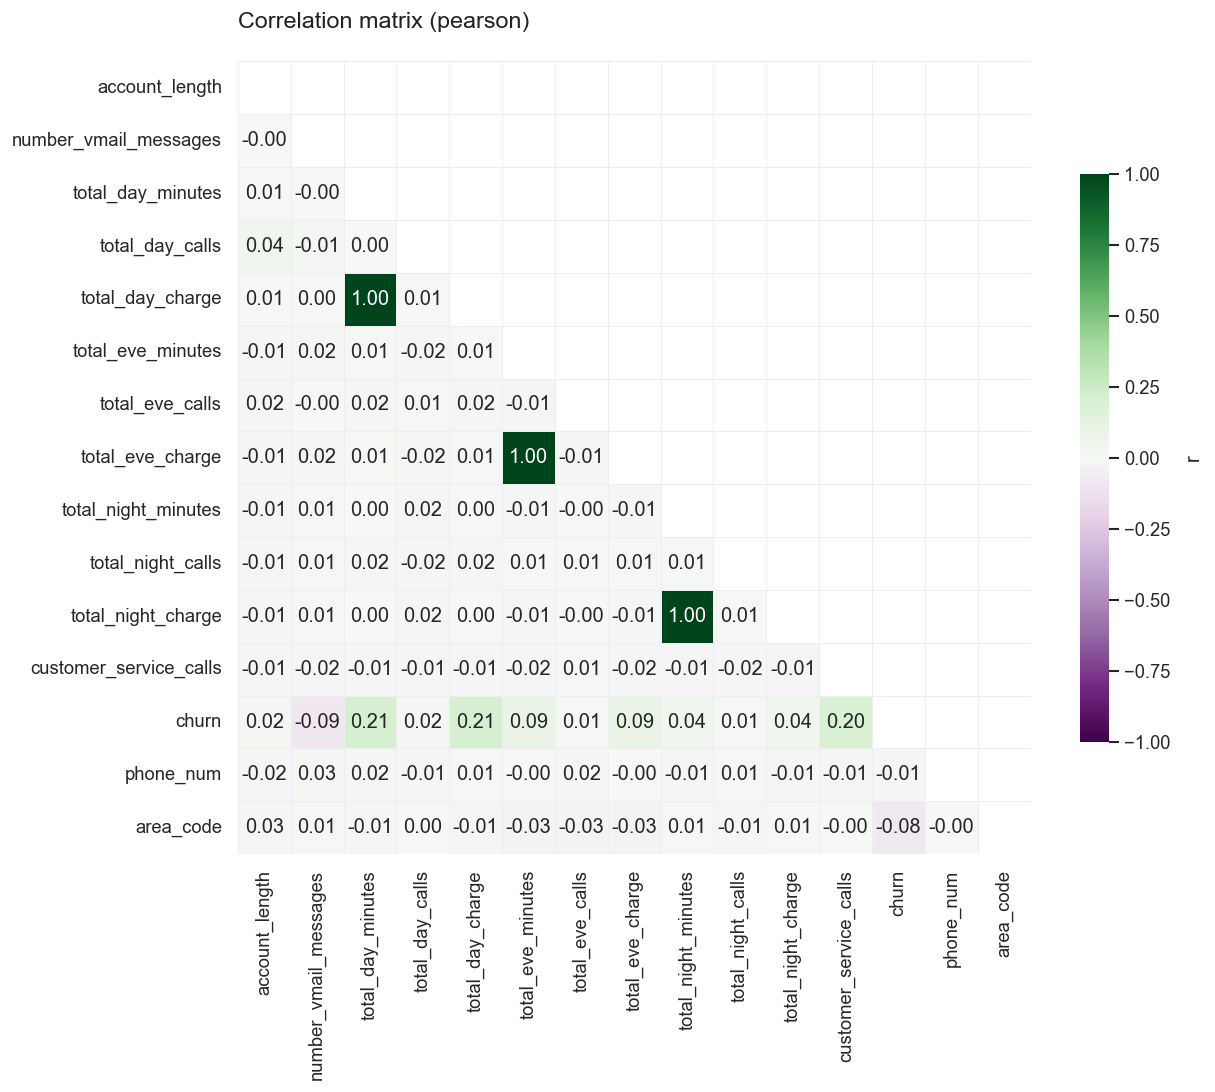

3 highly correlated pair(s) (|r| ≥ 0.8): total_day_minutes↔total_day_charge, total_night_minutes↔total_night_charge, total_eve_minutes↔total_eve_charge


⚠  3 highly correlated pair(s) (|r| ≥ 0.8): total_day_minutes↔total_day_charge, total_night_minutes↔total_night_charge, total_eve_minutes↔total_eve_charge


{'matrix':                         account_length  number_vmail_messages  \
 account_length                    1.00                  -0.00   
 number_vmail_messages            -0.00                   1.00   
 total_day_minutes                 0.01                  -0.00   
 total_day_calls                   0.04                  -0.01   
 total_day_charge                  0.01                   0.00   
 total_eve_minutes                -0.01                   0.02   
 total_eve_calls                   0.02                  -0.00   
 total_eve_charge                 -0.01                   0.02   
 total_night_minutes              -0.01                   0.01   
 total_night_calls                -0.01                   0.01   
 total_night_charge               -0.01                   0.01   
 customer_service_calls           -0.01                  -0.02   
 churn                             0.02                  -0.09   
 phone_num                        -0.02                   0.03   


In [9]:
inspect_correlations(df_eda)
# inspect_correlations(df_eda, target='your_target_col', show_pairplot=True)

### Outlier Detection

In [10]:
inspect_outliers(df_eda)
# inspect_outlier_detail(df_eda, 'your_col')


───  OUTLIERS  ───────────────────────────────────────────────


,column,mean,median,mean_med_diff,lower_1.5x,upper_1.5x,outliers_1.5x,outliers_1.5x_%,lower_3x,upper_3x,outliers_3x,outliers_3x_%
0,churn,0.14,0.00,0.14,0.00,0.00,483,14.49%,0.00,0.00,483,14.49%
1,customer_service_calls,1.53,1.00,0.53,-0.50,3.50,304,9.12%,-2.00,5.00,35,1.05%
2,total_night_minutes,200.87,201.20,-0.33,64.55,337.75,30,0.90%,-37.90,440.20,0,0.00%
3,total_night_charge,9.04,9.05,-0.01,2.91,15.20,30,0.90%,-1.69,19.80,0,0.00%
4,total_day_minutes,179.88,179.40,0.48,34.65,325.45,27,0.81%,-74.40,434.50,2,0.06%
5,total_day_charge,30.56,30.50,0.06,5.89,55.33,25,0.75%,-12.65,73.87,0,0.00%
6,total_eve_minutes,200.98,201.40,-0.42,63.55,338.35,24,0.72%,-39.50,441.40,0,0.00%
7,total_eve_charge,17.08,17.12,-0.04,5.40,28.76,24,0.72%,-3.36,37.52,0,0.00%
8,total_day_calls,100.41,101.00,-0.59,46.50,154.50,23,0.69%,6.00,195.00,2,0.06%
9,total_night_calls,100.12,100.00,0.12,48.00,152.00,22,0.66%,9.00,191.00,0,0.00%


→ inspect_outlier_detail(df, col) for boxplot+histogram per feature.


,column,mean,median,mean_med_diff,lower_1.5x,upper_1.5x,outliers_1.5x,outliers_1.5x_%,lower_3x,upper_3x,outliers_3x,outliers_3x_%
0,churn,0.14,0.00,0.14,0.00,0.00,483,14.49,0.00,0.00,483,14.49
1,customer_service_calls,1.53,1.00,0.53,-0.50,3.50,304,9.12,-2.00,5.00,35,1.05
2,total_night_minutes,200.87,201.20,-0.33,64.55,337.75,30,0.90,-37.90,440.20,0,0.00
3,total_night_charge,9.04,9.05,-0.01,2.91,15.20,30,0.90,-1.69,19.80,0,0.00
4,total_day_minutes,179.88,179.40,0.48,34.65,325.45,27,0.81,-74.40,434.50,2,0.06
5,total_day_charge,30.56,30.50,0.06,5.89,55.33,25,0.75,-12.65,73.87,0,0.00
6,total_eve_minutes,200.98,201.40,-0.42,63.55,338.35,24,0.72,-39.50,441.40,0,0.00
7,total_eve_charge,17.08,17.12,-0.04,5.40,28.76,24,0.72,-3.36,37.52,0,0.00
8,total_day_calls,100.41,101.00,-0.59,46.50,154.50,23,0.69,6.00,195.00,2,0.06
9,total_night_calls,100.12,100.00,0.12,48.00,152.00,22,0.66,9.00,191.00,0,0.00


### Features Inspection

* Engineering

In [11]:
# No new features planned in the EDA phase.
# The three indicator candidates (international_plan, customer_service_calls, total_day_minutes)
# are evaluated directly from the raw columns in 03_analysis.

## Key Findings

| # | Finding | Implikation |
|---|---------|-------------|
| 1 | Baseline Churn-Rate liegt bei 14.49% | Referenzwert fuer alle Vergleiche in 03_analysis |
| 2 | 16 Zeilen sind vollstaendig leer (NaN in allen Spalten) | In 02_preparation per `dropna(how='all')` entfernen |
| 3 | 4 Spalten haben zusaetzliche Teil-NaNs ueber die 16 leeren Zeilen hinaus: `number_vmail_messages` (38), `total_day_calls` (27), `total_eve_calls` (24), `total_night_calls` (21) | Domain-spezifische Auffuellung in 02_preparation (0 bzw. Median) |
| 4 | `customer_service_calls` enthaelt 37 Zeilen mit negativen Werten (-1, -2) | Datenfehler, nicht plausibel fuer einen Call-Counter -- Clipping auf 0 in 02_preparation |
| 5 | `total_day_minutes`/`total_day_charge`, `total_eve_minutes`/`total_eve_charge`, `total_night_minutes`/`total_night_charge` sind jeweils fast perfekt korreliert (|r| ≥ 0.8) | Charge ist eine Funktion der Minuten -- fuer die Indikator-Analyse reicht je ein Vertreter pro Paar |